# QQQ (Invesco QQQ Trust)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib


%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "QQQ_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

# Clustering

#### K-means

0. date formatting

In [3]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
categorized_df

0    1999-03-11
1    1999-03-12
2    1999-03-23
3    1999-03-24
4    1999-03-25
5    1999-03-26
6    1999-03-31
7    1999-04-01
8    1999-04-07
9    1999-04-08
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4231 entries, 0 to 4230
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             4231 non-null   datetime64[ns]
 1   Open             4231 non-null   float64       
 2   High             4231 non-null   float64       
 3   Low              4231 non-null   float64       
 4   Close            4231 non-null   float64       
 5   Volume           4231 non-null   int64         
 6   Open_category    4231 non-null   object        
 7   High_category    4231 non-null   object        
 8   Low_ca

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,1999-03-11,45.994,46.260,44.988,45.880,21670048,"(44.998, 47.088]","(45.505, 47.593]","(44.8, 46.887]","(45.124, 47.216]","(19838994.529, 22246375.057]"
1,1999-03-12,45.721,45.749,44.406,44.770,19553768,"(44.998, 47.088]","(45.505, 47.593]","(42.713, 44.8]","(43.033, 45.124]","(17263097.362000003, 19838994.529]"
2,1999-03-23,44.991,45.160,43.567,43.650,24517597,"(42.908, 44.998]","(43.417, 45.505]","(42.713, 44.8]","(43.033, 45.124]","(22246375.057, 24653755.586]"
3,1999-03-24,44.045,45.164,43.374,45.136,18890150,"(42.908, 44.998]","(43.417, 45.505]","(42.713, 44.8]","(45.124, 47.216]","(17263097.362000003, 19838994.529]"
4,1999-03-25,45.829,46.776,45.529,46.776,18192179,"(44.998, 47.088]","(45.505, 47.593]","(44.8, 46.887]","(45.124, 47.216]","(17263097.362000003, 19838994.529]"
...,...,...,...,...,...,...,...,...,...,...,...
4226,2017-11-03,152.390,153.290,151.840,153.270,26199249,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(24653755.586, 27061136.114]"
4227,2017-11-06,153.130,153.850,153.100,153.750,28685854,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(27061136.114, 29468516.643]"
4228,2017-11-07,153.670,154.082,153.340,153.870,21285469,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(19838994.529, 22246375.057]"
4229,2017-11-09,153.260,153.770,152.110,153.690,40554952,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(39098038.757, 41505419.286]"


1. add features

In [4]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df['Day'] = categorized_df['Date'].dt.day
categorized_df['Day_of_Week'] = categorized_df['Date'].dt.day_name()  # یا .dt.weekday برای مقدار عددی
categorized_df

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month,Day,Day_of_Week
0,1999-03-11,45.994,46.260,44.988,45.880,21670048,"(44.998, 47.088]","(45.505, 47.593]","(44.8, 46.887]","(45.124, 47.216]","(19838994.529, 22246375.057]",1999,3,11,Thursday
1,1999-03-12,45.721,45.749,44.406,44.770,19553768,"(44.998, 47.088]","(45.505, 47.593]","(42.713, 44.8]","(43.033, 45.124]","(17263097.362000003, 19838994.529]",1999,3,12,Friday
2,1999-03-23,44.991,45.160,43.567,43.650,24517597,"(42.908, 44.998]","(43.417, 45.505]","(42.713, 44.8]","(43.033, 45.124]","(22246375.057, 24653755.586]",1999,3,23,Tuesday
3,1999-03-24,44.045,45.164,43.374,45.136,18890150,"(42.908, 44.998]","(43.417, 45.505]","(42.713, 44.8]","(45.124, 47.216]","(17263097.362000003, 19838994.529]",1999,3,24,Wednesday
4,1999-03-25,45.829,46.776,45.529,46.776,18192179,"(44.998, 47.088]","(45.505, 47.593]","(44.8, 46.887]","(45.124, 47.216]","(17263097.362000003, 19838994.529]",1999,3,25,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4226,2017-11-03,152.390,153.290,151.840,153.270,26199249,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(24653755.586, 27061136.114]",2017,11,3,Friday
4227,2017-11-06,153.130,153.850,153.100,153.750,28685854,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(27061136.114, 29468516.643]",2017,11,6,Monday
4228,2017-11-07,153.670,154.082,153.340,153.870,21285469,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(19838994.529, 22246375.057]",2017,11,7,Tuesday
4229,2017-11-09,153.260,153.770,152.110,153.690,40554952,"(151.58, 153.67]","(151.994, 154.082]","(151.253, 153.34]","(151.779, 153.87]","(39098038.757, 41505419.286]",2017,11,9,Thursday


2. Feature normalization

In [5]:
# Select features for clustering
features = ['Volume', 'High', 'Low', 'Month', 'Day']
data_for_clustering = categorized_df[features]

# Data normalization
scaler = StandardScaler()
normalized_data = scaler.fit_transform(data_for_clustering)


3. Selecting the number of clusters</br>
To select the optimal number of clusters, use the Elbow Method:

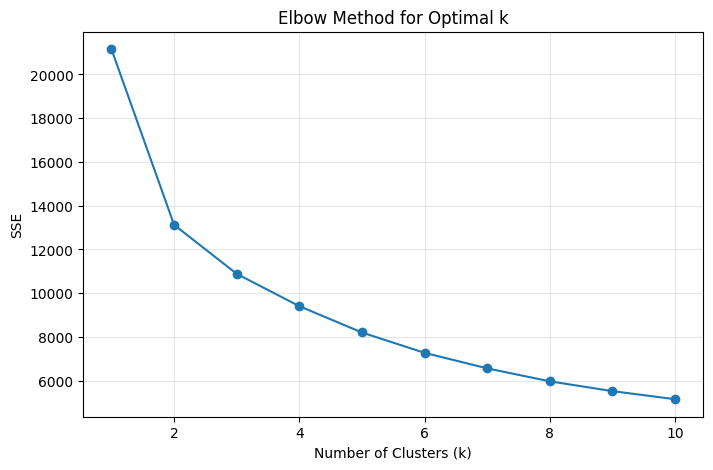

In [6]:
# Calculate SSE for different values of k
sse = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)  # Explicitly set n_init=10
    kmeans.fit(normalized_data)
    sse.append(kmeans.inertia_)

# Draw Elbow Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.grid(alpha=0.3)
plt.show()

# The optimal number of clusters is at the point where the graph has a significant change (skeletal).

Clustering with K-Means

In [7]:
# K-Means with optimal number of clusters (k=2)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
categorized_df['Cluster3'] = kmeans.fit_predict(normalized_data)

# Check cluster assignments
print(categorized_df['Cluster3'].value_counts())


Cluster3
1    1529
0    1486
2    1216
Name: count, dtype: int64


In [8]:
# K-Means with optimal number of clusters (k=2)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
categorized_df['Cluster'] = kmeans.fit_predict(normalized_data)

# Check cluster assignments
print(categorized_df['Cluster'].value_counts())


Cluster
0    2794
1    1437
Name: count, dtype: int64


Clustering Visualization

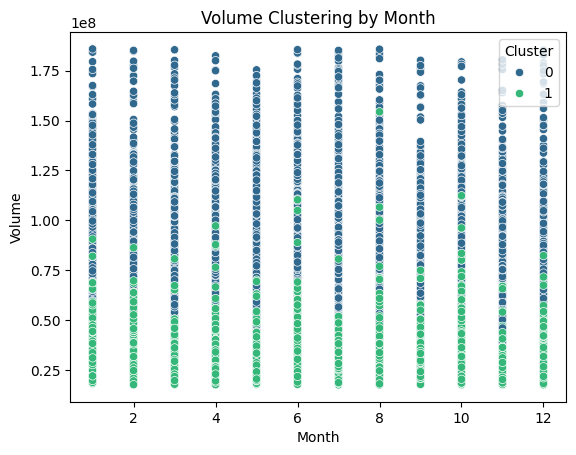

In [9]:
sns.scatterplot(
    x='Month', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Month")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

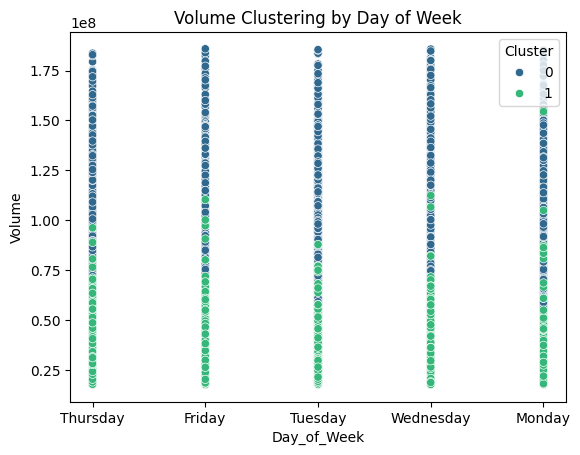

In [10]:
sns.scatterplot(
    x='Day_of_Week', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Day of Week")
plt.xlabel("Day_of_Week")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

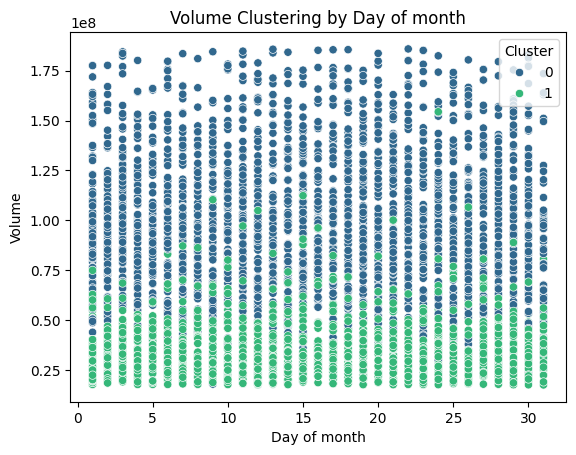

In [11]:
sns.scatterplot(
    x='Day', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Day of month")
plt.xlabel("Day of month")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

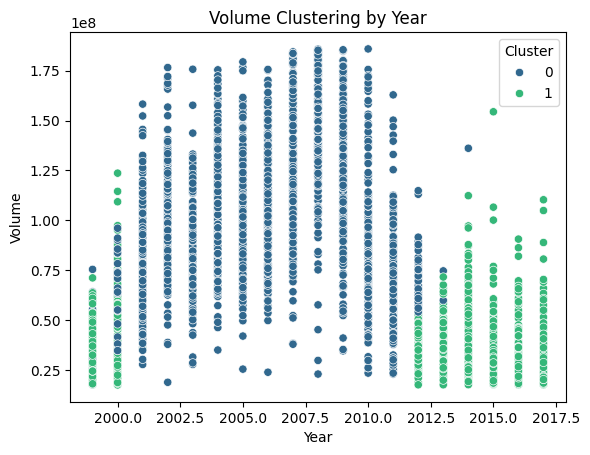

In [12]:
sns.scatterplot(
    x='Year', y='Volume', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Volume Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.legend(title="Cluster")
plt.show()

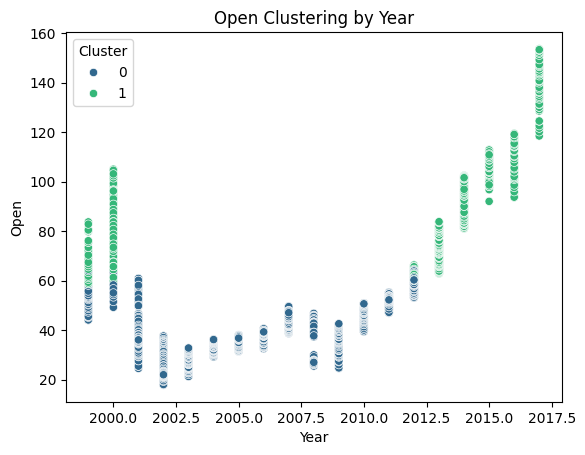

In [13]:
sns.scatterplot(
    x='Year', y='Open', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("Open Clustering by Year")
plt.xlabel("Year")
plt.ylabel("Open")
plt.legend(title="Cluster")
plt.show()

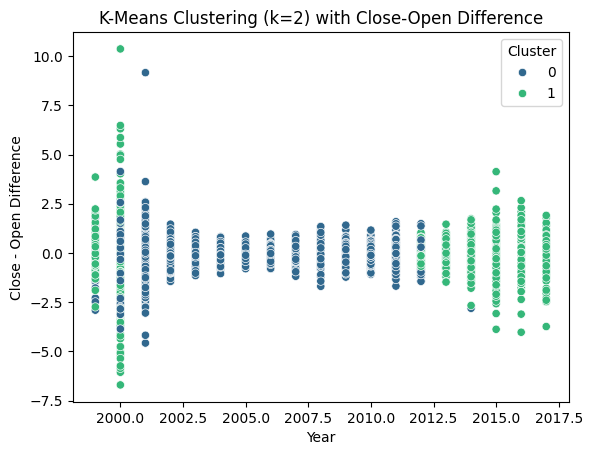

In [14]:
# Create a new column for the difference between Close and Open
categorized_df['Close_Open_Diff'] = categorized_df['Close'] - categorized_df['Open']

# Scatter plot with the difference as y-axis
sns.scatterplot(
    x='Year', y='Close_Open_Diff', hue='Cluster', data=categorized_df, palette='viridis'
)
plt.title("K-Means Clustering (k=2) with Close-Open Difference")
plt.xlabel("Year")
plt.ylabel("Close - Open Difference")
plt.legend(title="Cluster")
plt.show()


تحلیل زمانی خوشه‌ها

Examining seasonal patterns </br>
breaking down clusters by month, day of the week, or year

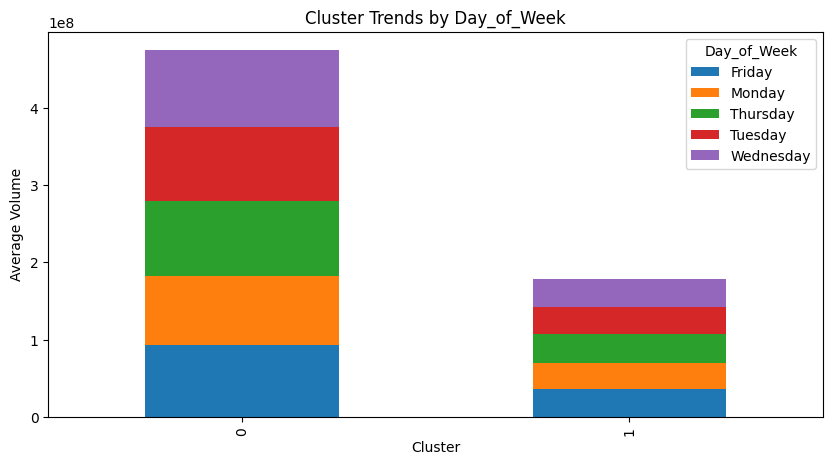

In [15]:
cluster_trends = categorized_df.groupby(['Cluster', 'Day_of_Week'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Day_of_Week")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


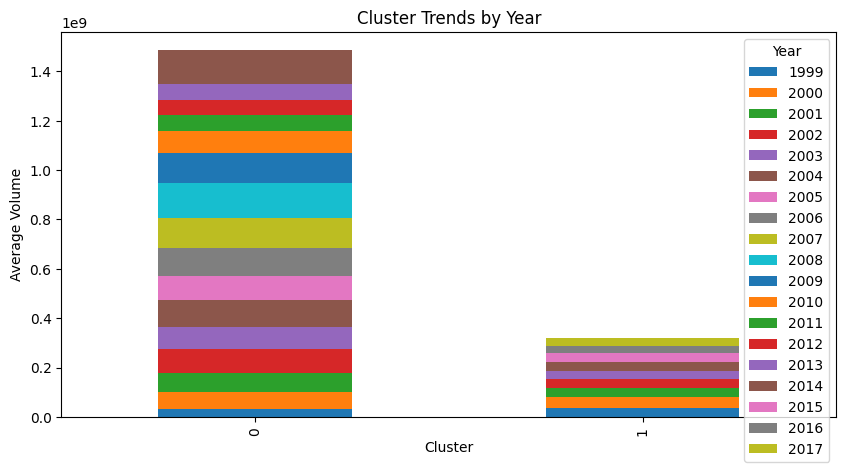

In [16]:
cluster_trends = categorized_df.groupby(['Cluster', 'Year'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Year")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


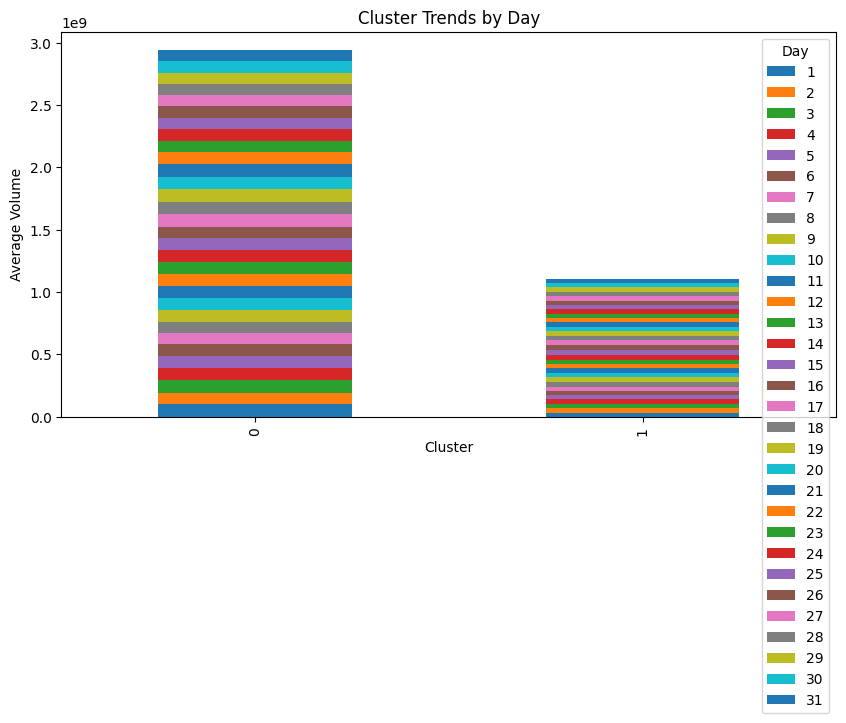

In [17]:
cluster_trends = categorized_df.groupby(['Cluster', 'Day'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Day")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()


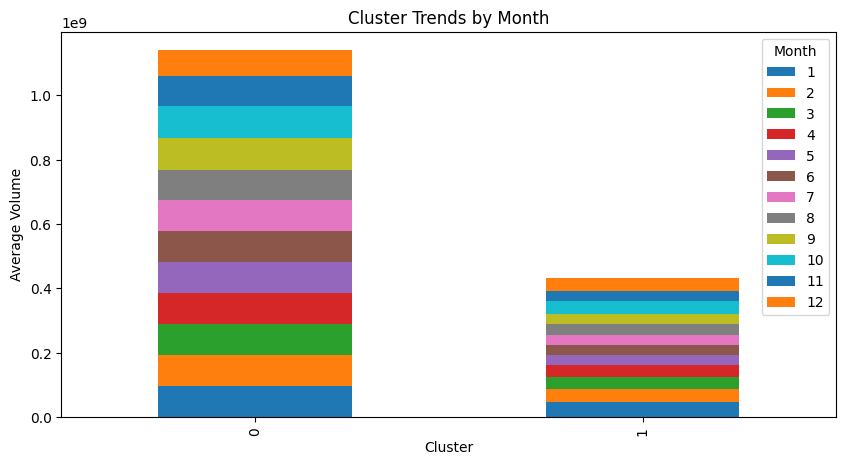

In [18]:
cluster_trends = categorized_df.groupby(['Cluster', 'Month'])['Volume'].mean()
# print(cluster_trends)

cluster_trends.unstack().plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title("Cluster Trends by Month")
plt.xlabel("Cluster")
plt.ylabel("Average Volume")
plt.show()
